In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

# Bank Marketing Campaign Analysis

## Business Problem

A Portuguese bank ran a series of telephone marketing campaigns to encourage clients to subscribe to **term deposits** — a savings product where a client locks money in an account for a fixed period in exchange for a guaranteed interest rate.

The core business challenge is **efficiency**: calling every client is costly, and the overall conversion rate is low (~11%). A well-performing classifier can help the bank:
- Identify clients most likely to subscribe *before* making the call
- Reduce wasted outreach on unlikely prospects
- Prioritize high-value segments in future campaigns

---

## Data Overview

| Dataset | File | Rows | Columns | Notes |
|---|---|---|---|---|
| Small (15-feature) | `bank.csv` | 4,521 | 17 | Stratified subset |
| Full (15-feature) | `bank-full.csv` | 45,211 | 17 | **Primary EDA dataset** |
| Additional (20-feature) | `bank-additional-full.csv` | 41,188 | 21 | Adds macroeconomic indicators, will explore separately |

The **15-feature format** (`bank-full.csv`) is used throughout this notebook. The 20-feature format will be explored in a second modeling notebook (time permitting).

In [168]:
df = pd.read_csv("../data/bank.csv", sep=";")
df.sample(n=10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2687,45,technician,married,secondary,no,1673,no,no,cellular,23,oct,76,1,-1,0,unknown,no
3780,26,management,single,tertiary,no,170,no,no,cellular,15,jun,129,1,-1,0,unknown,yes
3318,69,retired,married,secondary,no,745,no,no,telephone,9,sep,595,1,-1,0,unknown,no
2913,58,retired,married,secondary,no,413,no,no,cellular,27,aug,104,5,-1,0,unknown,no
1998,53,services,married,secondary,no,1378,yes,no,cellular,18,jul,91,2,-1,0,unknown,no
1582,46,blue-collar,married,primary,no,2558,yes,no,telephone,20,nov,107,1,167,1,other,no
3872,29,services,single,secondary,no,209,yes,no,cellular,28,jul,487,7,-1,0,unknown,no
3208,30,blue-collar,married,primary,no,-518,yes,yes,unknown,28,may,244,6,-1,0,unknown,no
3034,29,services,married,primary,no,-102,no,no,unknown,4,jul,134,1,-1,0,unknown,no
1795,35,admin.,single,secondary,no,2830,no,no,unknown,20,jun,22,12,-1,0,unknown,no


In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [170]:
df_full_additional = pd.read_csv("../data/bank-additional-full.csv", sep=";")
df_full_additional.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [171]:
df_full = pd.read_csv("../data/bank-full.csv", sep=";")
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [172]:
df_full.dropna()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## 2. Target Class Distribution

The target variable `y` indicates whether a client subscribed to a term deposit. The dataset is heavily **imbalanced** — understanding the baseline rate is critical before interpreting any model's accuracy.

y
no     39922
yes     5289
Name: count, dtype: int64

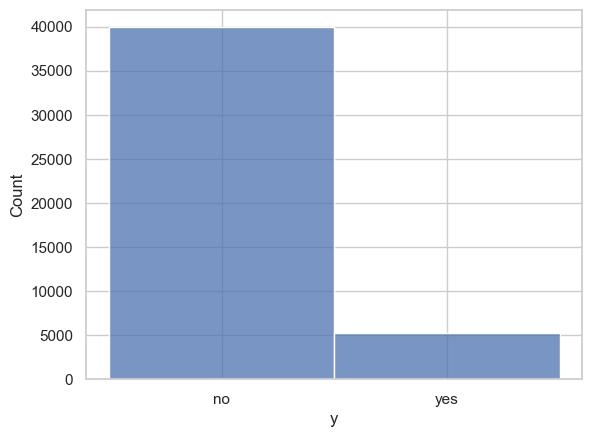

In [173]:
sns.histplot(df_full, x="y")
df_full['y'].value_counts()

**Key Finding:** ~88.5% of clients said *no*, giving a naive baseline accuracy of 88.5% — any model must meaningfully beat this to be useful. This class imbalance also means **accuracy alone is a misleading metric**; precision, recall, and F1-score will be more informative for evaluating classifier performance.

## 3. Categorical columns

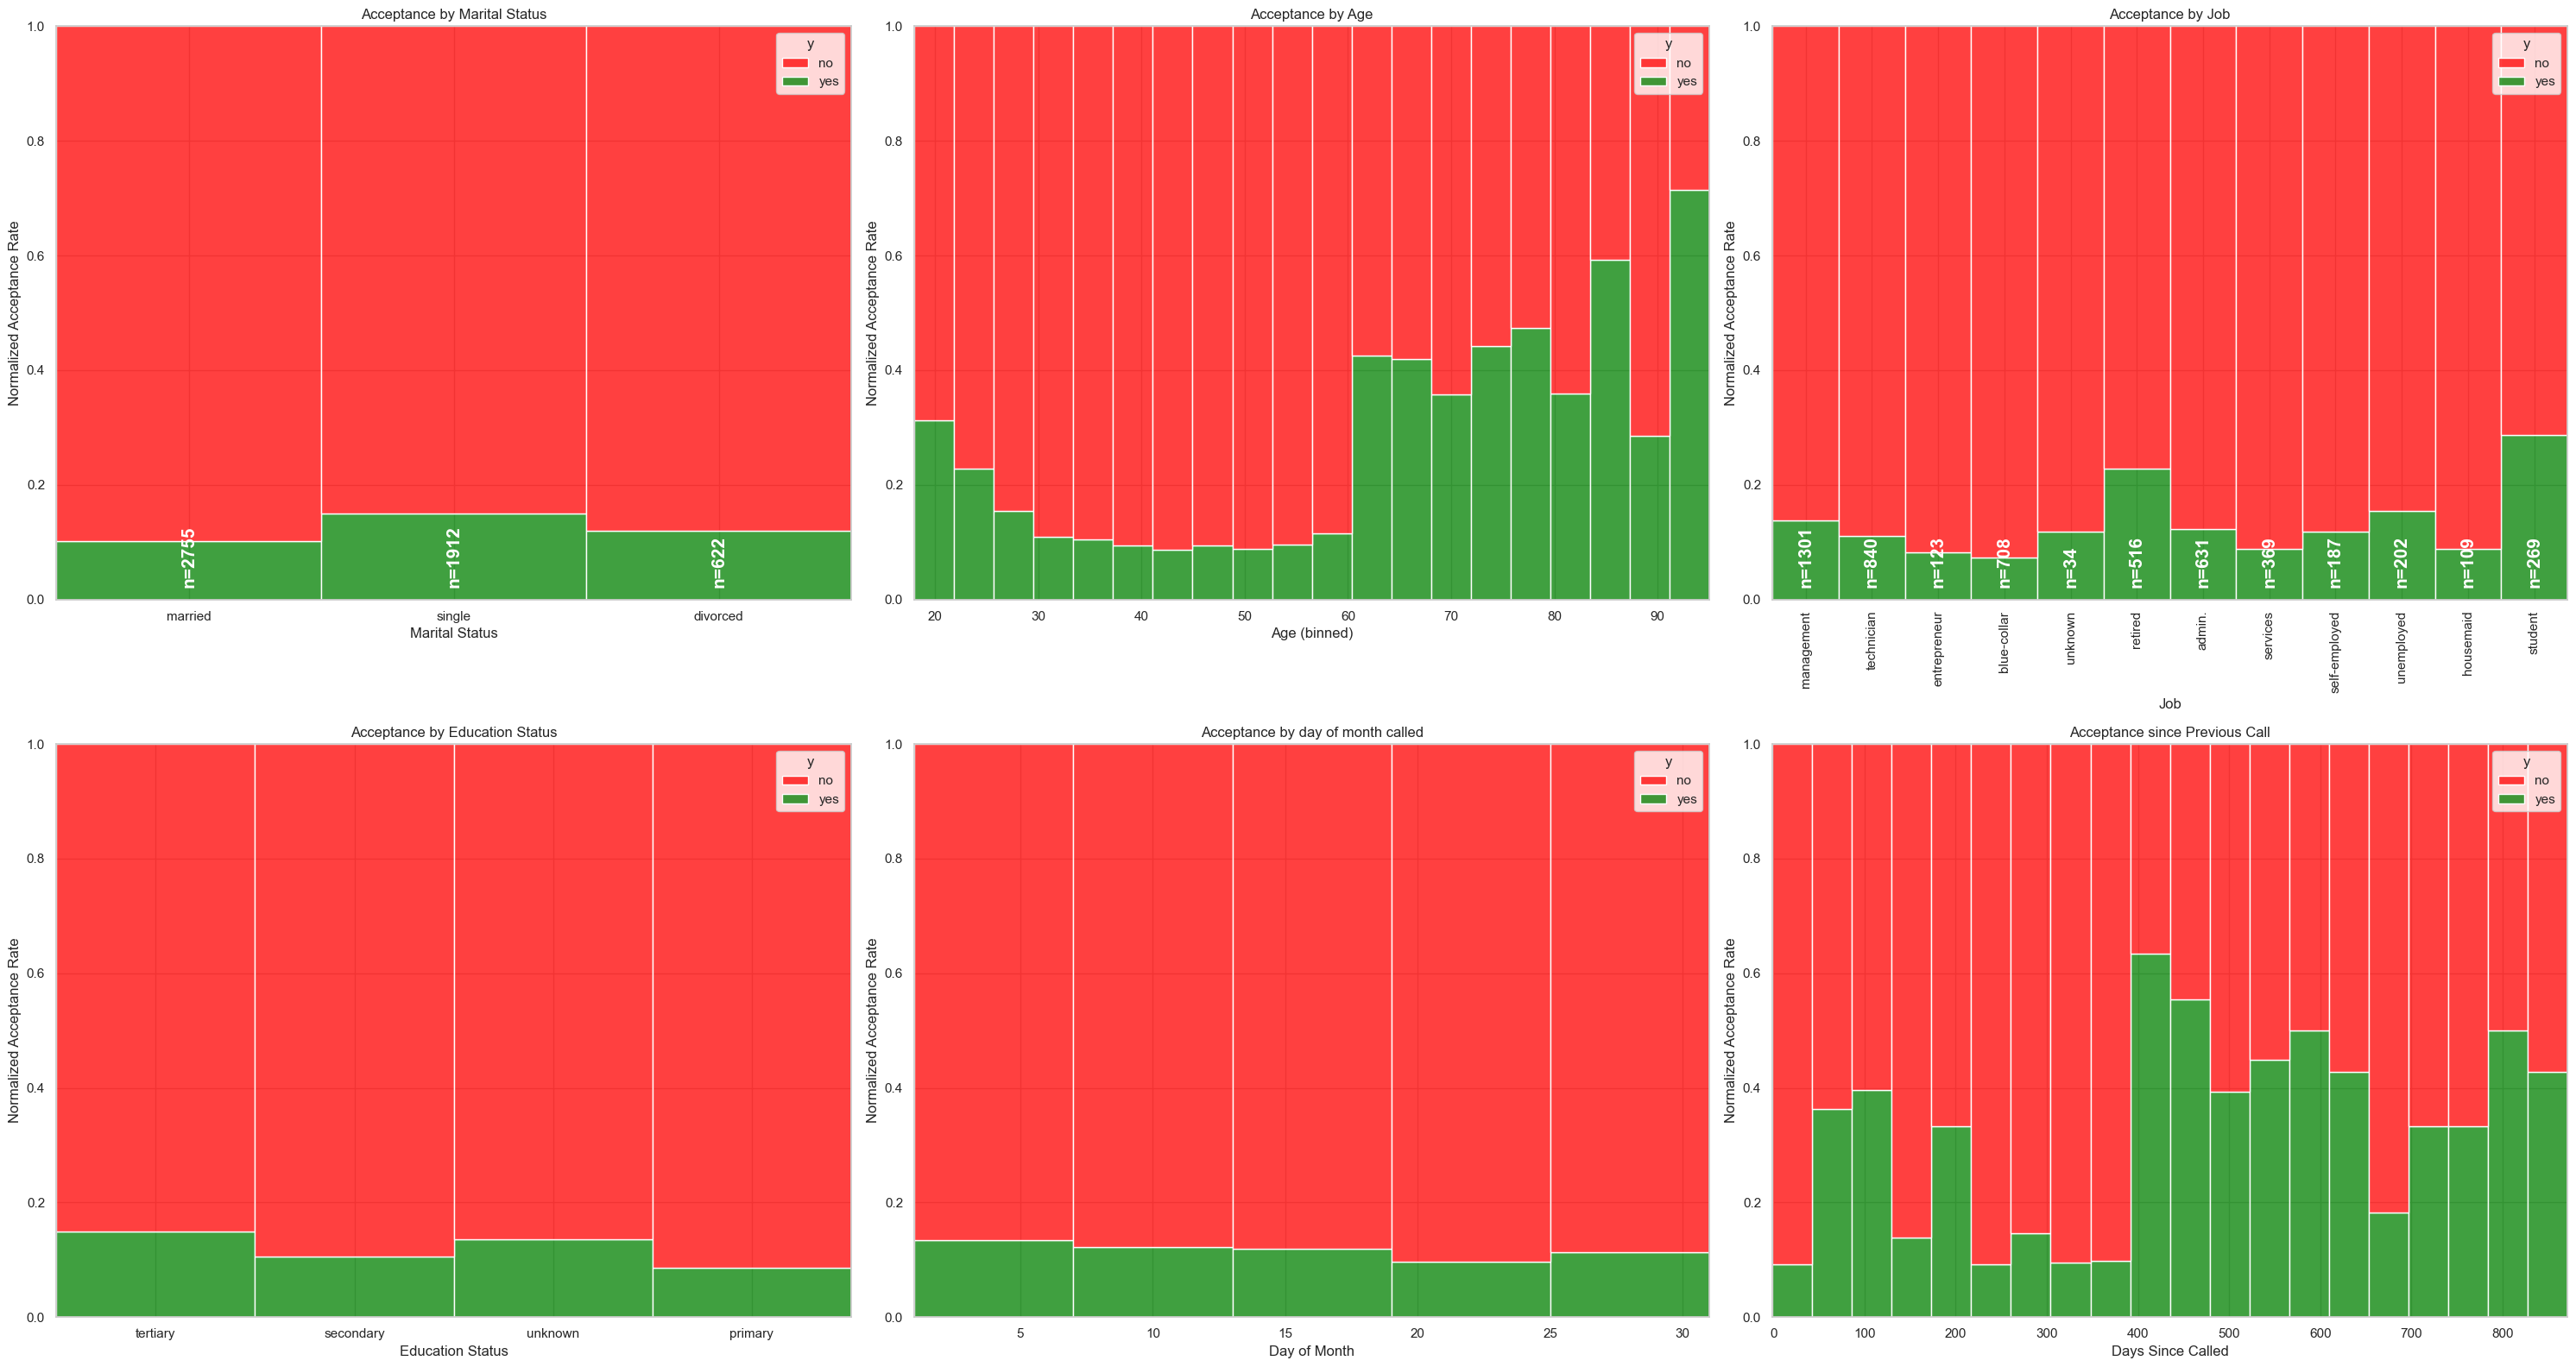

In [174]:
def annotate_yes_counts(ax, data, x_col, hue_col='y', yes_val='yes'):
    """Annotate a fill-normalized histplot with raw yes counts per category."""
    yes_counts = data[data[hue_col] == yes_val].groupby(x_col).size()
    tick_labels = [t.get_text() for t in ax.get_xticklabels()]
    tick_locs   = [t.get_position()[0] for t in ax.get_xticklabels()]
    for loc, label in zip(tick_locs, tick_labels):
        if label in yes_counts.index:
            ax.text(loc, 0.02, f'n={yes_counts[label]}',
                    ha='center', va='bottom', fontsize=15, rotation=90,
                    color='white', fontweight='bold',
                    transform=ax.get_xaxis_transform())

# ── Plot config ─────────────────────────────────────────────────────────────
# (column, title, x-label, bins, rotate_x, annotate_counts)
plot_configs = [
    ('marital',   'Acceptance by Marital Status',       'Marital Status',    3,    False, True),
    ('age',       'Acceptance by Age',                  'Age (binned)',      20,   False, False),
    ('job',       'Acceptance by Job',                  'Job',               None, True,  True),
    ('education', 'Acceptance by Education Status',     'Education Status',  None, False, False),
    ('day',       'Acceptance by day of month called', 'Day of Month',     5, False, False),
    ('pdays',     'Acceptance since Previous Call',     'Days Since Called', 20,   False, False),
]

PALETTE = {'yes': 'green', 'no': 'red'}
N_COLS  = 3
n_rows  = -(-len(plot_configs) // N_COLS)   # ceiling division — auto-adjusts if configs change

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(10 * N_COLS, 8 * n_rows))

for ax, (col, title, xlabel, bins, rotate, annotate) in zip(axes.flat, plot_configs):
    sns.histplot(
        data=df_full, x=col, hue='y',
        palette=PALETTE, multiple='fill',
        bins=bins if bins else 'auto',
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Normalized Acceptance Rate')
    if rotate:
        ax.tick_params(axis='x', rotation=90)
    if annotate:
        annotate_yes_counts(ax, df_full, col)

# Hide any unused subplots if plot_configs count isn't a multiple of N_COLS
for ax in axes.flat[len(plot_configs):]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()


# ===================================================================
# This was the original code that was rewritten by claude for brevity above
# ===================================================================
# def annotate_yes_counts(ax, data, x_col, hue_col='y', yes_val='yes'):
#     """Annotate a fill-normalized histplot with raw yes counts per category."""
#     yes_counts = data[data[hue_col] == yes_val].groupby(x_col).size()
#     tick_labels = [t.get_text() for t in ax.get_xticklabels()]
#     tick_locs   = [t.get_position()[0] for t in ax.get_xticklabels()]

#     for loc, label in zip(tick_locs, tick_labels):
#         if label in yes_counts.index:
#             ax.text(loc, 0.02, f'n={yes_counts[label]}',
#                     ha='center', va='bottom',
#                     fontsize=15, rotation=90,
#                     color='white', fontweight='bold',
#                     transform=ax.get_xaxis_transform())  # x in data, y in axes coords

# fig, axes = plt.subplots(2, 3, figsize=(30, 15))

# sns.histplot(data=df_full, x='marital',     hue='y', palette={'yes': 'green', 'no': 'red'}, multiple='fill', bins=3, ax=axes[0,0])
# sns.histplot(data=df_full, x='age',         hue='y', palette={'yes': 'green', 'no': 'red'}, multiple='fill', bins=20, ax=axes[0, 1])
# sns.histplot(data=df_full, x='job',         hue='y', palette={'yes': 'green', 'no': 'red'}, multiple='fill', ax=axes[0, 2])

# # second row
# sns.histplot(data=df_full, x='education',   hue='y', palette={'yes': 'green', 'no': 'red'}, multiple='fill', ax=axes[1, 0])
# sns.histplot(data=df_full, x='month',       hue='y', palette={'yes': 'green', 'no': 'red'}, multiple='fill', ax=axes[1, 1])
# sns.histplot(data=df_full, x='pdays',       hue='y', palette={'yes': 'green', 'no': 'red'}, multiple='fill', bins=20, ax=axes[1, 2])

# annotate_yes_counts(axes[0, 0], df_full, 'marital')
# annotate_yes_counts(axes[0, 2], df_full, 'job')

# axes[0,2].tick_params(axis='x', rotation=90)

# axes[0, 0].set_title('Acceptance by Marital Status')
# axes[0, 0].set_xlabel('Marital Status')
# axes[0, 0].set_ylabel('Normalized Acceptance Rate by Marital Status')

# axes[0, 1].set_title('Acceptance by Age')
# axes[0, 1].set_xlabel('Age (binned)')
# axes[0, 1].set_ylabel('Normalized Acceptance Rate by Age')

# axes[0, 2].set_title('Acceptance by Job')
# axes[0, 2].set_xlabel('Job')
# axes[0, 2].set_ylabel('Normalized Acceptance Rate by Job')

# axes[1, 0].set_title('Acceptance by Education Status')
# axes[1, 0].set_xlabel('Education Status')
# axes[1, 0].set_ylabel('Normalized Acceptance Rate by Education Status')

# axes[1, 1].set_title('Acceptance by Month of Year Called')
# axes[1, 1].set_xlabel('Month of Year')
# axes[1, 1].set_ylabel('Normalized Acceptance Rate by Month')

# axes[1, 2].set_title('Acceptance since Previous Call')
# axes[1, 2].set_xlabel('Previous Call')
# axes[1, 2].set_ylabel('Normalized Acceptance Rate by Previous Call')


# fig.tight_layout()
# ===================================================================


### Observations
1. No discernable pattern by marital status
2. Acceptance rates increase after 60
3. Retired and Students seem to accepting more, for students this is likely their first account
4. No visible pattern emerges from Education Status (**the education status holds some relevance from categorical values and can likely use Nominal encoder**)
5. No visible trend by day of month called, but there is a small slope from the beginning to the end of the month 
6. Acceptance rates are higher if you call back after 2 months or after 1 year. Follow ups can help improve acceptance rate even if the first call was not successful. 

## 4. Campaign Contact Patterns

How the *timing* and *method* of outreach affect conversion — and whether calling a client multiple times helps or hurts.

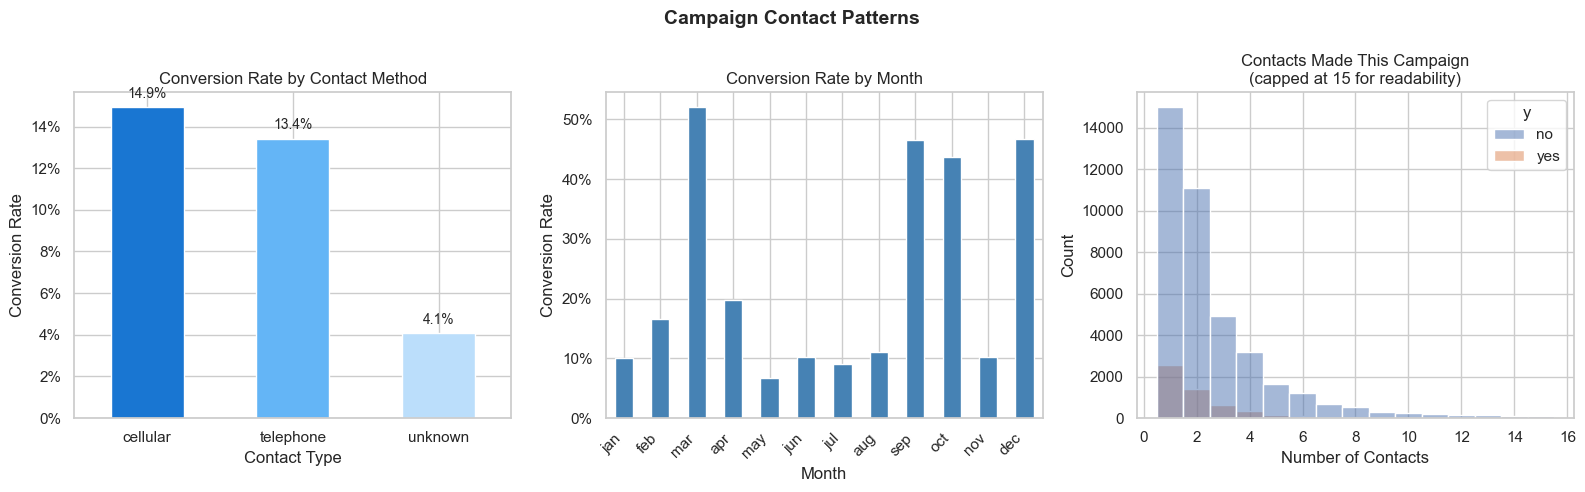

In [175]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Contact method conversion rate
contact_rate = (
    df_full.groupby('contact')['y']
    .apply(lambda x: (x == 'yes').mean())
    .sort_values(ascending=False)
)
contact_rate.plot(kind='bar', ax=axes[0],
                  color=['#1976D2', '#64B5F6', '#BBDEFB'], edgecolor='white')
axes[0].set_title('Conversion Rate by Contact Method')
axes[0].set_xlabel('Contact Type')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

# Month conversion rate (calendar order)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_rate = (
    df_full.groupby('month')['y']
    .apply(lambda x: (x == 'yes').mean())
    .reindex(month_order)
    .dropna()
)
month_rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Conversion Rate by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Number of contacts made this campaign (cap at 15 for readability)
campaign_capped = df_full[df_full['campaign'] <= 15]
sns.histplot(data=campaign_capped, x='campaign', hue='y',
             bins=15, discrete=True, ax=axes[2])
axes[2].set_title('Contacts Made This Campaign\n(capped at 15 for readability)')
axes[2].set_xlabel('Number of Contacts')
axes[2].set_ylabel('Count')

plt.suptitle('Campaign Contact Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations
1. Contacting by telephone is better than whatever the unknown method (door to door?) was
2. Acceptrance rates seem to be higher towards the end of the year (Q4 - Sept through Dec, except Nov) and in March, likely signifying some local trend related to taxation. November lull can be a sandwhich effect. 


C:\Users\anant\AppData\Local\Temp\ipykernel_13112\2635396626.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='y', y='duration',
C:\Users\anant\AppData\Local\Temp\ipykernel_13112\2635396626.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Yes'])
C:\Users\anant\AppData\Local\Temp\ipykernel_13112\2635396626.py:38: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\anant\AppData\Local\Temp\ipykernel_13112\2635396626.py:38: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\tools\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) 

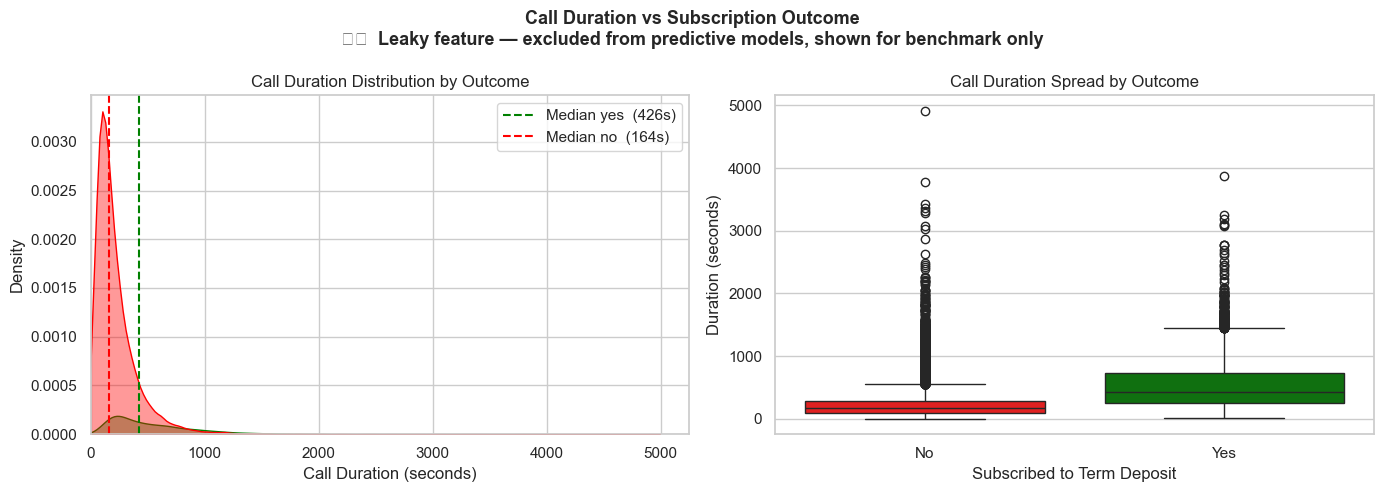

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(
    data=df_full, x='duration', hue='y',
    palette={'yes': 'green', 'no': 'red'},
    fill=True, alpha=0.4, ax=axes[0],
)
median_yes = df_full[df_full['y'] == 'yes']['duration'].median()
median_no  = df_full[df_full['y'] == 'no']['duration'].median()
axes[0].axvline(median_yes, color='green', linestyle='--', linewidth=1.5,
                label=f'Median yes  ({median_yes:.0f}s)')
axes[0].axvline(median_no,  color='red',   linestyle='--', linewidth=1.5,
                label=f'Median no  ({median_no:.0f}s)')
axes[0].set_title('Call Duration Distribution by Outcome')
axes[0].set_xlabel('Call Duration (seconds)')
axes[0].set_ylabel('Density')
axes[0].set_xlim(left=0)
axes[0].legend()


sns.boxplot(data=df_full, x='y', y='duration',
            palette={'yes': 'green', 'no': 'red'}, ax=axes[1])
axes[1].set_title('Call Duration Spread by Outcome')
axes[1].set_xlabel('Subscribed to Term Deposit')
axes[1].set_ylabel('Duration (seconds)')
axes[1].set_xticklabels(['No', 'Yes'])

plt.suptitle('Call Duration vs Subscription Outcome\n'
             'Leaky feature — excluded from predictive models, shown for benchmark only',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

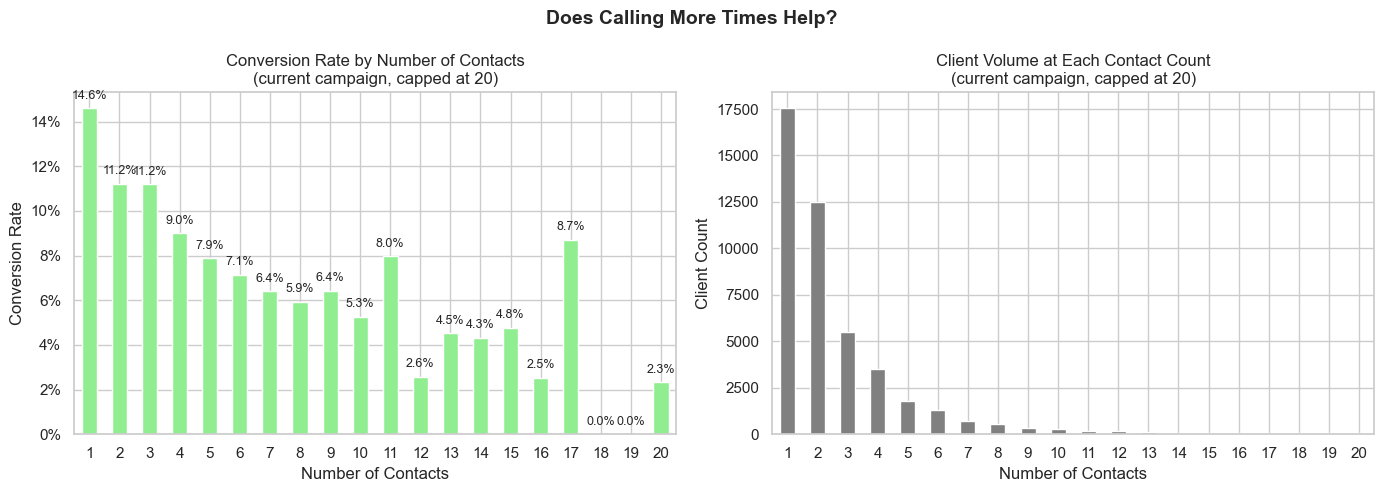

In [189]:

MAX_CONTACTS = 20
capped = df_full[df_full['campaign'] <= MAX_CONTACTS]

campaign_rate   = capped.groupby('campaign')['y'].apply(lambda x: (x == 'yes').mean())
campaign_counts = capped['campaign'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: conversion rate per contact attempt
campaign_rate.plot(kind='bar', ax=axes[0], color='lightgreen', edgecolor='white')
axes[0].set_title('Conversion Rate by Number of Contacts\n(current campaign, capped at 20)')
axes[0].set_xlabel('Number of Contacts')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)


campaign_counts.plot(kind='bar', ax=axes[1], color='gray', edgecolor='white')
axes[1].set_title('Client Volume at Each Contact Count\n(current campaign, capped at 20)')
axes[1].set_xlabel('Number of Contacts')
axes[1].set_ylabel('Client Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.suptitle('Does Calling More Times Help?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Financial Profile

Clients without a housing loan or personal loan show higher conversion rates, suggesting that existing debt obligations reduce willingness to commit to another financial product.

C:\Users\anant\AppData\Local\Temp\ipykernel_13112\3760796257.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trimmed, x='y', y='balance', ax=axes[0], palette={'yes': 'green', 'no': 'red'})
C:\Users\anant\AppData\Local\Temp\ipykernel_13112\3760796257.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Yes'])


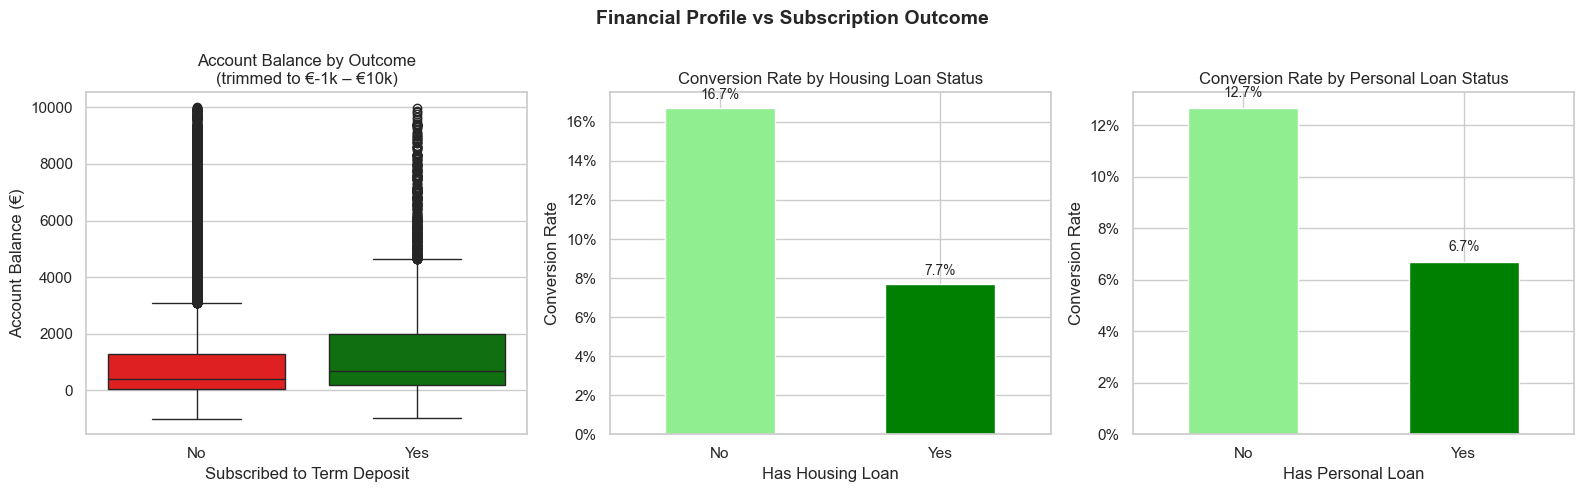

In [178]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Account balance by outcome (trim outliers for readability)
trimmed = df_full[df_full['balance'].between(-1000, 10000)]
sns.boxplot(data=trimmed, x='y', y='balance', ax=axes[0], palette={'yes': 'green', 'no': 'red'})
axes[0].set_title('Account Balance by Outcome\n(trimmed to €-1k – €10k)')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_ylabel('Account Balance (€)')
axes[0].set_xticklabels(['No', 'Yes'])

housing_rate = df_full.groupby('housing')['y'].apply(lambda x: (x == 'yes').mean())
housing_rate.plot(kind='bar', ax=axes[1], color=['lightgreen', 'green'], edgecolor='white')
axes[1].set_title('Conversion Rate by Housing Loan Status')
axes[1].set_xlabel('Has Housing Loan')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

loan_rate = df_full.groupby('loan')['y'].apply(lambda x: (x == 'yes').mean())
loan_rate.plot(kind='bar', ax=axes[2], color=[ 'lightgreen', 'green'], edgecolor='white')
axes[2].set_title('Conversion Rate by Personal Loan Status')
axes[2].set_xlabel('Has Personal Loan')
axes[2].set_ylabel('Conversion Rate')
axes[2].set_xticklabels(['No', 'Yes'], rotation=0)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Financial Profile vs Subscription Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations 
1. Acceptance rates can approximately `double` for someone who already does not have a housing or a personal loan

## 6. Previous Campaign Influence

Clients who said *yes* in a previous campaign are far more likely to convert again. `poutcome` is one of the strongest predictors in the dataset.

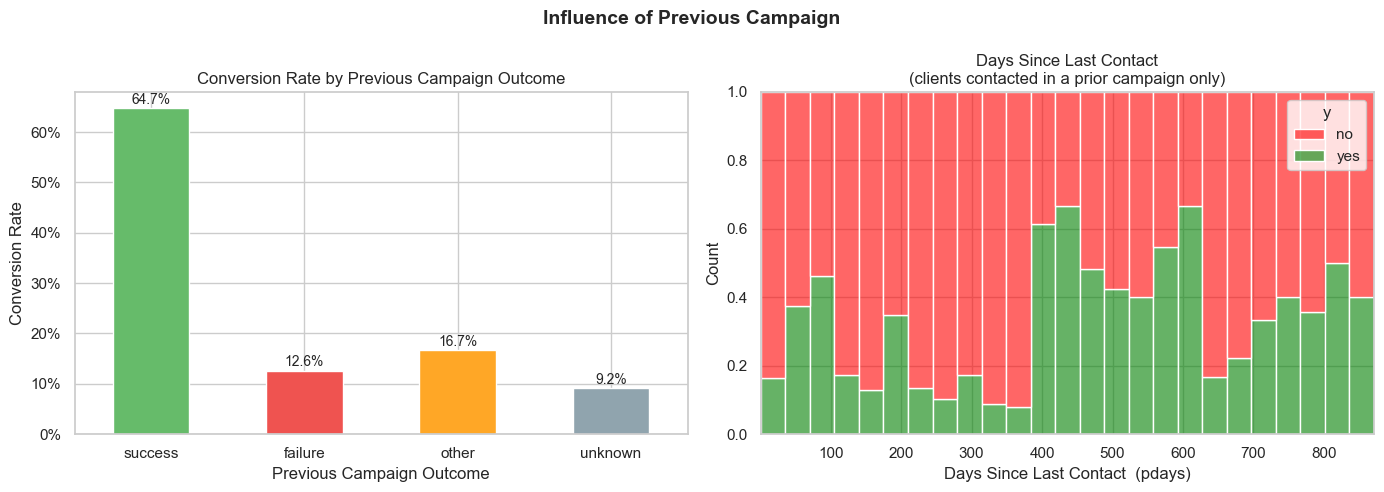

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

poutcome_order = ['success', 'failure', 'other', 'unknown']
poutcome_rate = (
    df_full.groupby('poutcome')['y']
    .apply(lambda x: (x == 'yes').mean())
    .reindex(poutcome_order)
    .dropna()
)
bar_colors = ['#66BB6A', '#EF5350', '#FFA726', '#90A4AE']
poutcome_rate.plot(kind='bar', ax=axes[0], color=bar_colors[:len(poutcome_rate)], edgecolor='white')
axes[0].set_title('Conversion Rate by Previous Campaign Outcome')
axes[0].set_xlabel('Previous Campaign Outcome')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

prev_contacted = df_full[df_full['pdays'] > 0]
sns.histplot(data=prev_contacted, x='pdays', hue='y',  palette={'yes': 'green', 'no': 'red'}, alpha=0.6, bins=25, multiple='fill', ax=axes[1])
axes[1].set_title('Days Since Last Contact\n(clients contacted in a prior campaign only)')
axes[1].set_xlabel('Days Since Last Contact  (pdays)')
axes[1].set_ylabel('Count')

plt.suptitle('Influence of Previous Campaign', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation** : From the second chart it appears that if you contact someone between 1 and 2 years after initial contact, you have a better conversion rate. If declined, do not call them again for about a year. 

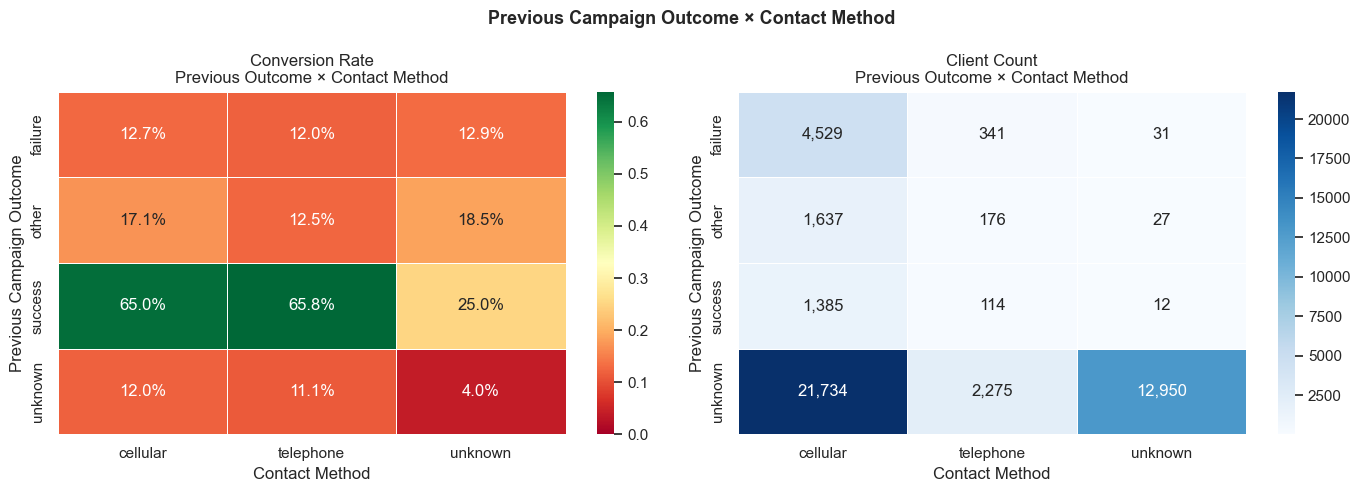

In [191]:

# A prior success + cellular contact is a qualitatively different profile
# than either factor alone — this heatmap makes that visible.

rate_pivot  = (
    df_full.groupby(['poutcome', 'contact'])['y']
    .apply(lambda x: (x == 'yes').mean())
    .unstack()
)
count_pivot = df_full.groupby(['poutcome', 'contact']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.heatmap(
    rate_pivot, annot=True, fmt='.1%',
    cmap='RdYlGn', linewidths=0.5,
    vmin=0, vmax=rate_pivot.values.max(),
    ax=axes[0],
)
axes[0].set_title('Conversion Rate\nPrevious Outcome × Contact Method')
axes[0].set_xlabel('Contact Method')
axes[0].set_ylabel('Previous Campaign Outcome')


sns.heatmap(
    count_pivot, annot=True, fmt=',d',
    cmap='Blues', linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title('Client Count\nPrevious Outcome × Contact Method')
axes[1].set_xlabel('Contact Method')
axes[1].set_ylabel('Previous Campaign Outcome')

plt.suptitle('Previous Campaign Outcome × Contact Method',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Numeric Correlations & Feature Relationships

<Axes: >

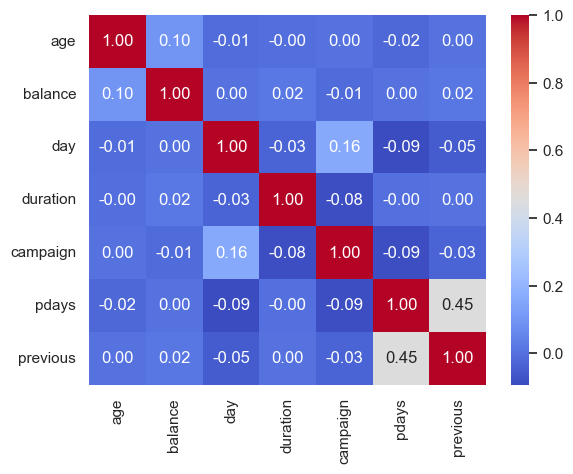

In [181]:
sns.heatmap(df_full.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm')

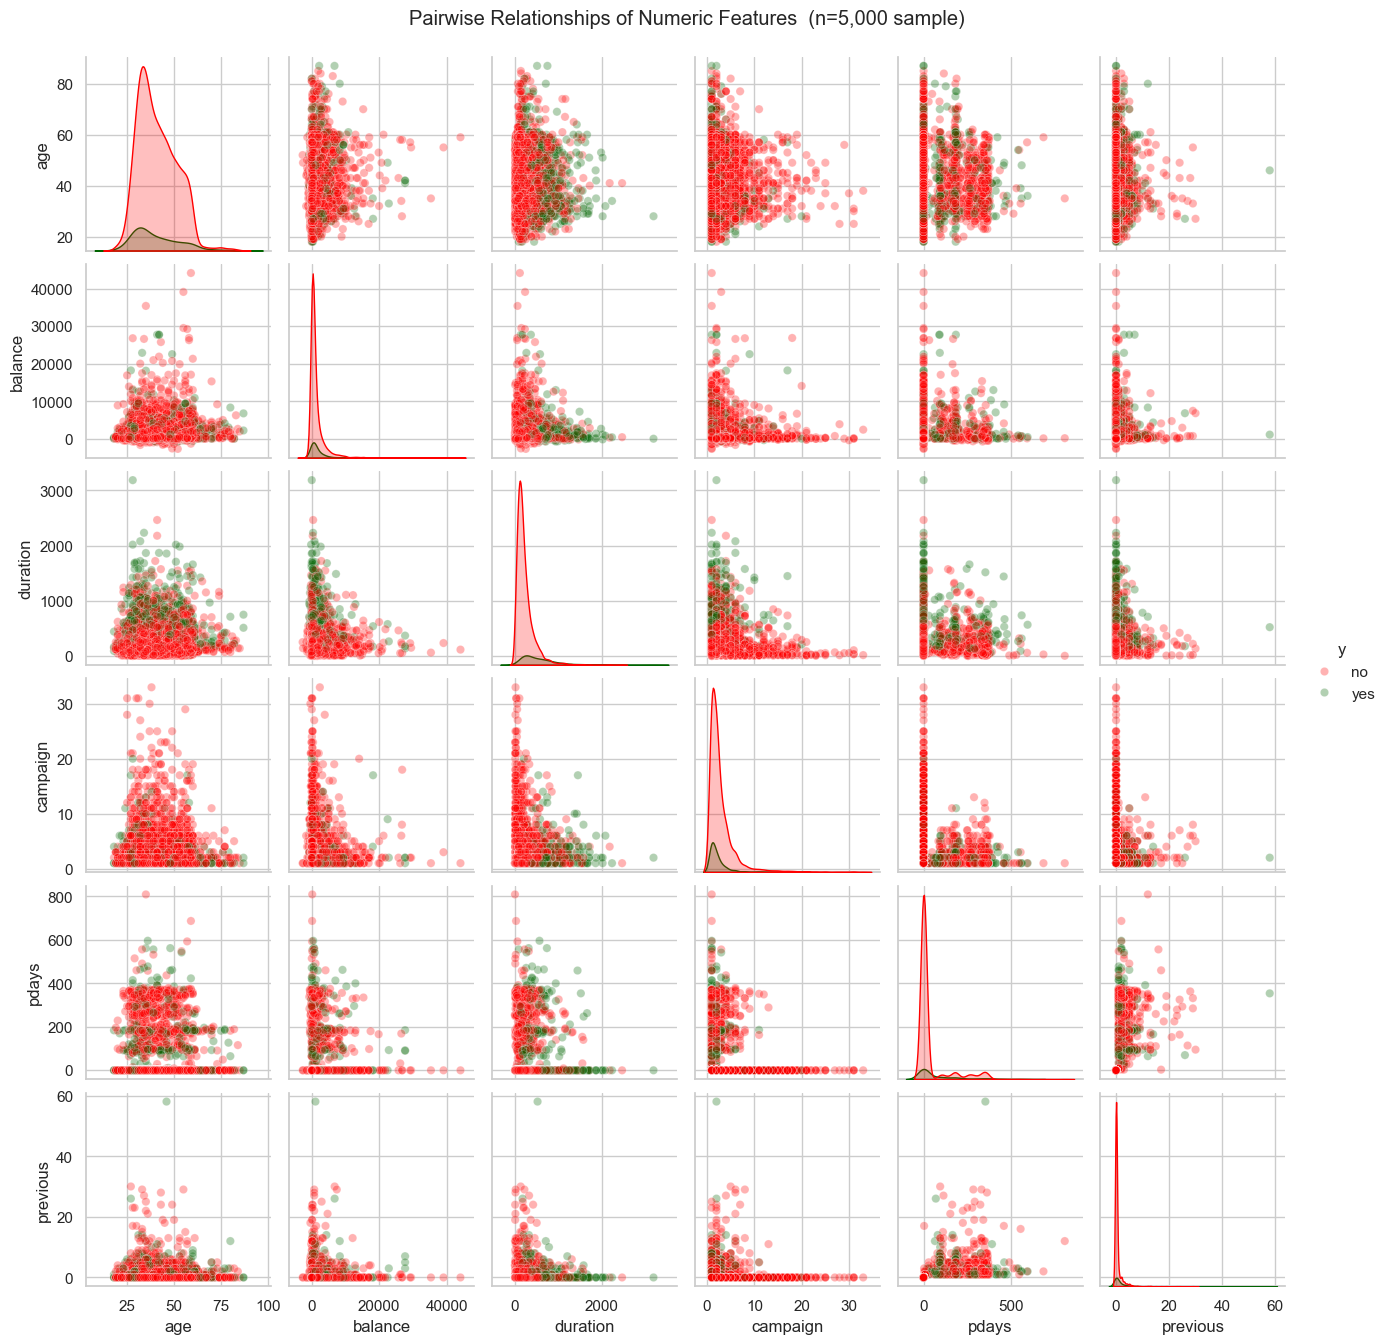

In [182]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
sample_df = df_full.sample(n=5_000, random_state=42) #too slow for full dataset

sns.pairplot(
    sample_df[numeric_cols + ['y']],
    hue='y',
    diag_kind='kde',
    palette={'yes': 'darkgreen', 'no': 'red'},
    plot_kws={'alpha': 0.3},
    height=2.2
)
plt.suptitle('Pairwise Relationships of Numeric Features  (n=5,000 sample)', y=1.02)
plt.show()

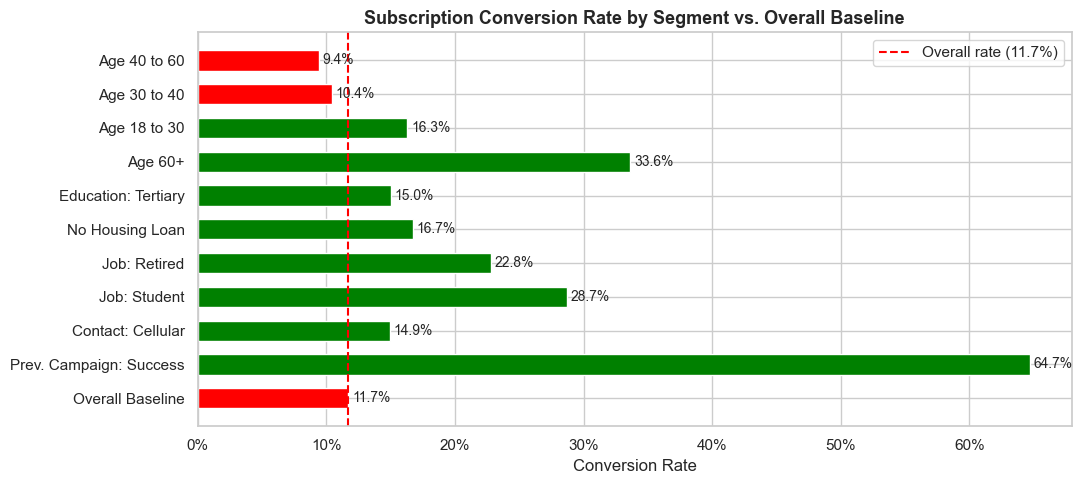

In [183]:
overall_rate = (df_full['y'] == 'yes').mean()

segments = {
    'Overall Baseline':          overall_rate,
    'Prev. Campaign: Success':   df_full[df_full['poutcome'] == 'success']['y'].eq('yes').mean(),
    'Contact: Cellular':         df_full[df_full['contact'] == 'cellular']['y'].eq('yes').mean(),
    'Job: Student':              df_full[df_full['job'] == 'student']['y'].eq('yes').mean(),
    'Job: Retired':              df_full[df_full['job'] == 'retired']['y'].eq('yes').mean(),
    'No Housing Loan':           df_full[df_full['housing'] == 'no']['y'].eq('yes').mean(),
    'Education: Tertiary':       df_full[df_full['education'] == 'tertiary']['y'].eq('yes').mean(),
    'Age 60+':                   df_full[df_full['age'] >= 60]['y'].eq('yes').mean(),
    'Age 18 to 30':              df_full[df_full['age'].between(18, 30)]['y'].eq('yes').mean(),
    'Age 30 to 40':              df_full[df_full['age'].between(30, 40)]['y'].eq('yes').mean(),
    'Age 40 to 60':              df_full[df_full['age'].between(40, 60)]['y'].eq('yes').mean(),
}

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['red' if k <= overall_rate else 'green' for k in segments.values()]
bars = ax.barh(list(segments.keys()), list(segments.values()),
               color=colors, edgecolor='white', height=0.6)

#create v line for vis baseline
ax.axvline(overall_rate, color='red', linestyle='--', linewidth=1.5,
           label=f'Overall rate ({overall_rate:.1%})')

#set axis percentage
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.set_title('Subscription Conversion Rate by Segment vs. Overall Baseline',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate')
ax.legend()
for bar, val in zip(bars, segments.values()):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## EDA Summary & Transition to Modeling

### Key Predictors Identified

The exploratory analysis surfaced a clear hierarchy of signal in the data:

| Feature | Type | Finding |
|---|---|---|
| `poutcome` | Categorical | Prior campaign success drives ~64% conversion vs. 11% baseline — strongest single predictor |
| `housing` / `loan` | Binary | No existing debt obligations roughly **doubles** conversion rate |
| `contact` | Categorical | Cellular outreach consistently outperforms telephone and unknown methods |
| `age` / `job` | Categorical | Retired and student segments convert at 2× the baseline; clients 60+ skew positive |
| `month` | Categorical | Q4 (Sep, Oct, Dec) and March show meaningfully higher conversion |
| `campaign` | Numeric | Conversion drops sharply after the 4th or 5th contact — diminishing returns are steep |

### Preprocessing Decisions Before Modeling

- **Drop `duration`** — leaky feature, known only after the call ends. Include one model run *with* it as a benchmark ceiling, then exclude it for all realistic comparisons
- **Encode categoricals** — `OrdinalEncoder` for `education` (ordered levels); `OneHotEncoder` for remaining nominal columns (`job`, `marital`, `contact`, `month`, `poutcome`)
- **Address class imbalance** — the 88.5% / 11.5% split means a model that predicts *no* for every row scores 88.5% accuracy. Use `class_weight='balanced'` or stratified splits, and evaluate on **F1-score (positive class)** and **ROC-AUC** rather than accuracy. 
    - Consider using `SMOTE` (Synthetic Minority Over-sampling TEchnique) if possible and time permits. Challenge will be several categorical columns, will have to execute SMOTE on the encoded values which can create fractional values between real world implications.  
- **Scale numeric features** — required for KNN, Logistic Regression, and SVM; Decision Trees are scale-invariant but scaling them does no harm in a shared pipeline

### Evaluation Metric Rationale

**Primary metric: F1-score (class = "yes")**
The bank's goal is to find the clients *most likely* to subscribe. False negatives (missed subscribers) waste opportunity; false positives (calling a non-subscriber) waste campaign budget. F1 balances both. ROC-AUC will be used as a secondary metric to compare overall classifier discrimination.

### Next Steps

The modeling notebook will train and compare four classifiers on the 15-feature dataset:

1. **K-Nearest Neighbors** - distance-based baseline
2. **Logistic Regression** - interpretable linear benchmark
3. **Decision Tree** - captures non-linear splits; useful for feature importance
4. **Support Vector Machine** - high-dimensional margin classifier

Each will be evaluated with cross-validation and tuned with grid search. The best-performing model's coefficients or feature importances will be interpreted against the segments identified in this analysis.